# 01 — Data Exploration

Profiles the processed Ohio analytical tables that feed the review-priority score: record counts, missingness, the size/score/tier distributions, and geometry-source confidence. All inputs are produced by `python src/run_pipeline.py`.

*This notebook reads the committed `data/processed/` outputs; re-run the pipeline first if you have changed the scoring code.*

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROC = REPO / 'data' / 'processed'
pd.set_option('display.max_columns', 40)
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.spines.top'] = plt.rcParams['axes.spines.right'] = False

## Load the core tables

In [2]:
master = pd.read_csv(PROC / 'water_system_master.csv', dtype={'pwsid': str, 'county_fips': str})
scores = pd.read_csv(PROC / 'water_system_risk_scores.csv', dtype={'pwsid': str})
geo = pd.read_csv(PROC / 'water_system_geography.csv', dtype={'pwsid': str, 'county_fips': str})
print(f'master:    {len(master):,} rows x {master.shape[1]} cols')
print(f'scores:    {len(scores):,} rows x {scores.shape[1]} cols')
print(f'geography: {len(geo):,} rows x {geo.shape[1]} cols')

master:    16,339 rows x 18 cols
scores:    16,339 rows x 23 cols
geography: 16,339 rows x 25 cols


## Missingness in the master table
Which inventory fields are incomplete — context for the data-quality penalty.

In [3]:
miss = master.isna().mean().sort_values(ascending=False)
miss = (miss[miss > 0] * 100).round(1)
miss.to_frame('percent_missing')

,percent_missing
county_fips,1.2
county,1.2
owner_type,0.6
city,0.5
primary_source_water_type,0.5
last_seen_date,0.1
pws_name,0.0


## System size distribution
The screen is aimed at small systems, which dominate the inventory.

,systems
system_size_class,
very_small,14693
small,1229
medium,210
large,207


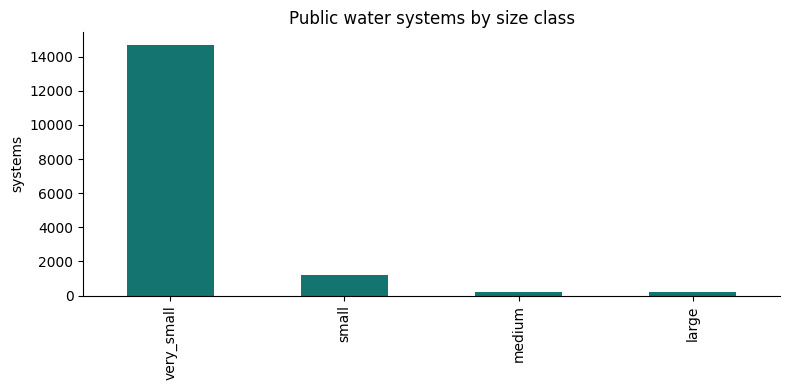

In [4]:
size_counts = master['system_size_class'].value_counts()
display(size_counts.to_frame('systems'))
ax = size_counts.reindex(['very_small','small','medium','large','unknown']).dropna().plot.bar(color='#14746f')
ax.set_title('Public water systems by size class'); ax.set_xlabel(''); ax.set_ylabel('systems')
plt.tight_layout(); plt.show()

## Review-priority score distribution and tiers

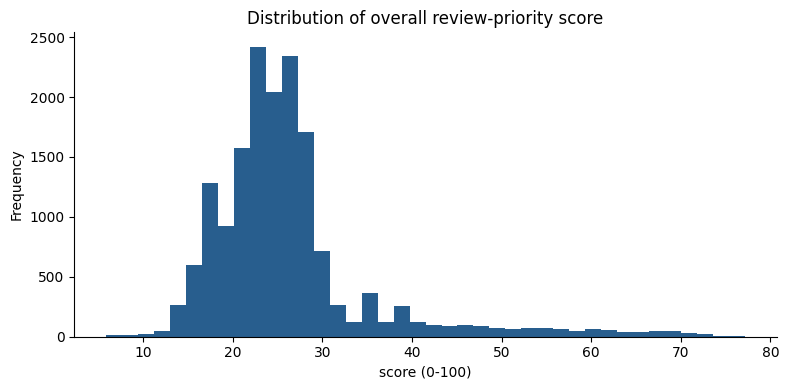

,systems
risk_tier,
Critical Review,NaN
High Review,188.0
Moderate Review,756.0
Monitor,6719.0
Lower Priority,8676.0


In [5]:
ax = scores['overall_risk_score'].plot.hist(bins=40, color='#285e8e')
ax.set_title('Distribution of overall review-priority score'); ax.set_xlabel('score (0-100)')
plt.tight_layout(); plt.show()
tier_order = ['Critical Review','High Review','Moderate Review','Monitor','Lower Priority']
scores['risk_tier'].value_counts().reindex(tier_order).to_frame('systems')

## Geometry source confidence
Real EPA service-area polygons where available; honest fallback otherwise.

In [6]:
geo['spatial_confidence'].value_counts().to_frame('systems')

,systems
spatial_confidence,
very_low,15070
medium_high,870
very_high,207
unknown,192


## Top counties by high-review systems

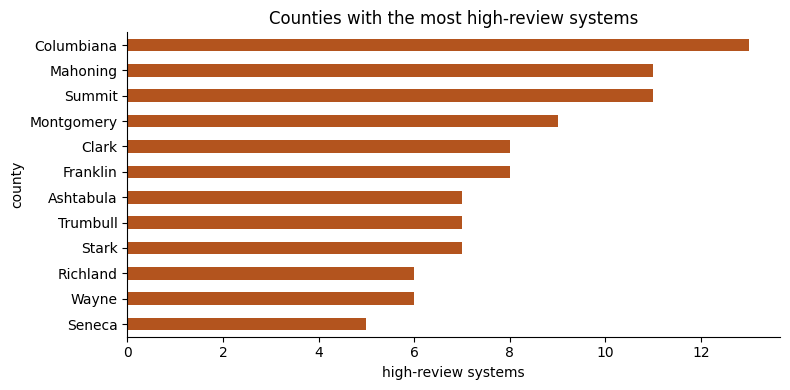

,high_review_systems
county,
Columbiana,13
Mahoning,11
Summit,11
Montgomery,9
Clark,8
Franklin,8
Ashtabula,7
Trumbull,7
Stark,7


In [7]:
high = scores[scores['risk_tier'].isin(['Critical Review','High Review'])]
top = high['county'].value_counts().head(12)
ax = top.iloc[::-1].plot.barh(color='#b3541e')
ax.set_title('Counties with the most high-review systems'); ax.set_xlabel('high-review systems')
plt.tight_layout(); plt.show()
top.to_frame('high_review_systems')